In [141]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta, poisson, lognorm, gamma
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd
from torch.distributions import Normal, LogNormal, Independent, Poisson
from sbi.utils import MultipleIndependent, BoxUniform

Gaussian Distribution


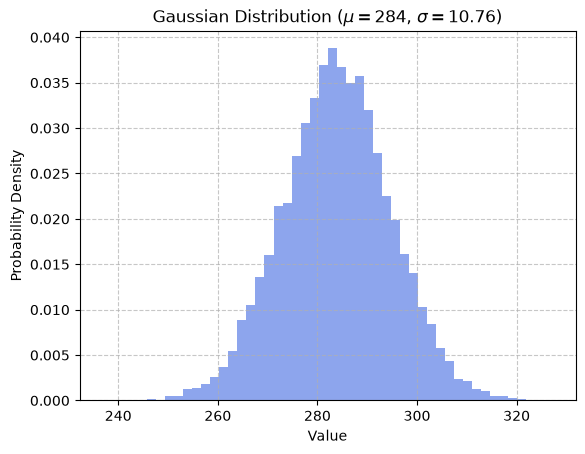

In [55]:
#set up a random gaussian
rng = np.random.default_rng(seed=42)

mu = 284  
sigma = 10.76   
N = 10000 
observed = rng.normal(loc=mu, scale=sigma, size=N)

plt.hist(observed, bins=50, density=True, alpha=0.6, color='royalblue')
plt.title(f"Gaussian Distribution ($\mu={mu}$, $\sigma={sigma}$)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


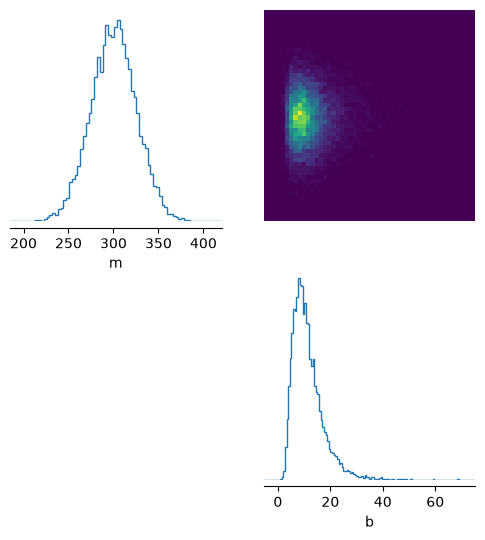

In [100]:
# and prior

prior = MultipleIndependent([
    Normal(torch.tensor([300.0], dtype=torch.float32),
           torch.tensor([25.0], dtype=torch.float32)),                 
    LogNormal(torch.tensor([math.log(10.0)], dtype=torch.float32),
              torch.tensor([0.5], dtype=torch.float32)),               
])

prior_samples = prior.sample((10000,))

fig, ax = pairplot(
    prior_samples,
    labels=["m", "b"],
    figsize=(6, 6)
)


In [ ]:
edges = np.linspace(230, 340, 51)
centers = 0.5 * (edges[:-1] + edges[1:])
x_grid = torch.tensor(centers, dtype=torch.float32)

import math
prior = MultipleIndependent([
    Normal(torch.tensor([300.0], dtype=torch.float32),
           torch.tensor([25.0], dtype=torch.float32)),                 
    LogNormal(torch.tensor([math.log(10.0)], dtype=torch.float32),
              torch.tensor([0.5], dtype=torch.float32)),               
])

noise_std = 0.001

def simulator(theta, x=x_grid):
    mu, sigma = theta[0], theta[1]
    pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * torch.exp(-0.5 * ((x - mu) / sigma) ** 2)
    return pdf + noise_std * torch.randn_like(pdf)

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(t) for t in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)


y_obs, _ = np.histogram(observed, bins=edges, density=True)
x_o = torch.tensor(y_obs, dtype=torch.float32)

post_samples = posterior.sample((5000,), x=x_o)
print(post_samples.mean(0), post_samples.std(0)) 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 44, 46, 47, 48, 49] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 292 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

tensor([283.8566,  10.7819]) tensor([0.2309, 0.1853])


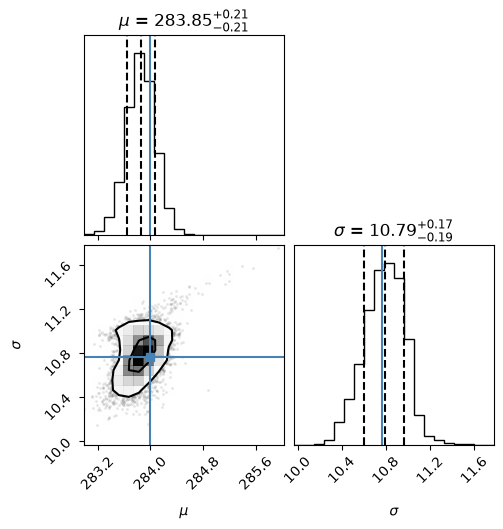

In [58]:
#Make corner plot
flat_samples = post_samples.numpy()

labels = [r"$\mu$", r"$\sigma$"]
truths = [mu, sigma]

fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})



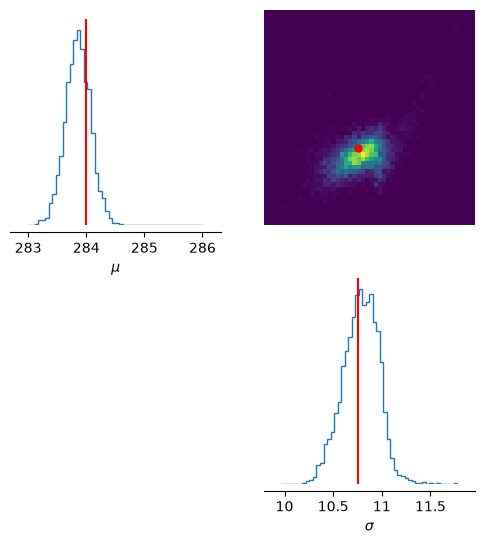

In [59]:
#plot the posterior from above
fig, axes = pairplot(
    post_samples,
    points=[[284.0, 10.76]],        
    points_colors=["red"],
    labels=[r"$\mu$", r"$\sigma$"],
    figsize=(6, 6),
)

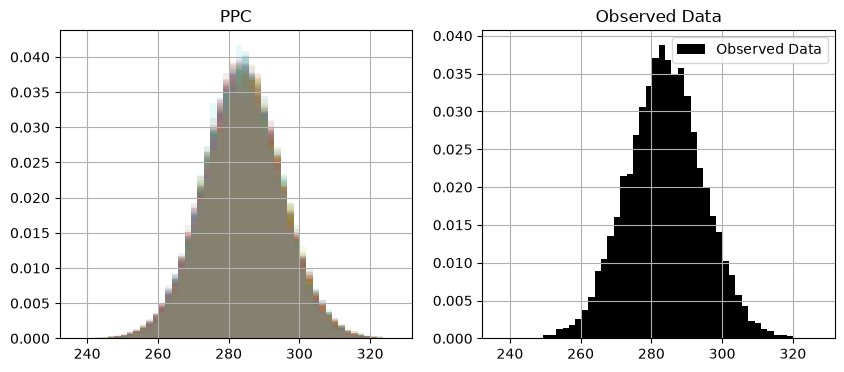

In [75]:
def replicate_posterior(theta_samp, n_obs, rng):
    theta_np = theta_samp.detach().cpu().numpy()
    mu = theta_np[:, 0][:, None]      
    sigma = theta_np[:, 1][:, None]  
    return rng.normal(loc=mu, scale=sigma, size=(len(theta_np), n_obs))  

rng = np.random.default_rng(0)
y_rep = replicate_posterior(posterior_samples, n_obs=len(observed), rng=rng)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10, 4))
bins = np.histogram_bin_edges(observed, bins=50)   

for i in range(100):
    ax1.hist(y_rep[i], bins=bins, density=True, alpha=0.1)

ax2.hist(observed, bins=bins, density=True,
        color='k', label='Observed Data')

ax1.set_title('PPC')
ax1.grid()
ax2.set_title('Observed Data')
ax2.grid()
ax2.legend()
plt.show()

Poisson Distribution

/var/folders/s1/xqf5j6t15yv8wdy04nnncvhc0000gn/T/ipykernel_4463/2425129786.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


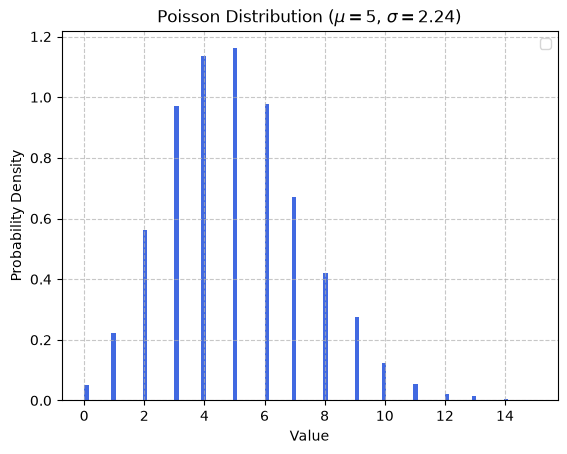

In [173]:
#set up poisson distribution
rng = np.random.default_rng(seed=42)

mu = 5   
sigma = np.sqrt(mu)
N = 10000 
observed = rng.poisson(mu, size=N)

plt.hist(observed, bins=100, density=True, color='royalblue')
plt.title(f"Poisson Distribution ($\mu={mu}$, $\sigma={sigma:.2f}$)")
plt.xlabel("Value")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

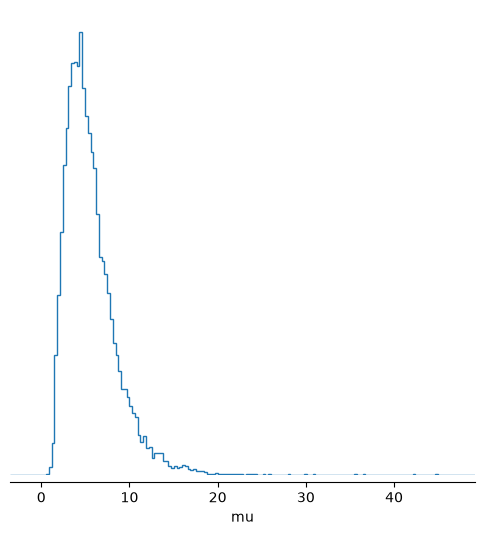

In [176]:
# and prior

prior = LogNormal(torch.tensor([math.log(5)]), torch.tensor([0.5]))

prior_samples = prior.sample((10000,))

fig, ax = pairplot(
    prior_samples,
    labels=["mu"],
    figsize=(6, 6)
)


In [175]:
edges = np.arange(9.5, 60.5, 1.0)             
centers = 0.5 * (edges[:-1] + edges[1:])      
x_grid = torch.tensor(centers, dtype=torch.float32)

noise_std = 0.001

def simulator(theta, x=x_grid):
    mu = theta[0]
    log_pmf = -mu + x * torch.log(mu) - torch.lgamma(x + 1)
    pmf = torch.exp(log_pmf)
    return pmf + noise_std * torch.randn_like(pmf)

n_simulations = 2000
theta_train = prior.sample((n_simulations,))
x_train = torch.stack([simulator(t) for t in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)


y_obs, _ = np.histogram(observed, bins=edges, density=True)
x_o = torch.tensor(y_obs, dtype=torch.float32)

post_samples = posterior.sample((5000,), x=x_o)
print(post_samples.mean(0), post_samples.std(0)) 


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 47, 48, 49] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/neural_nets/net_builders/flow.py:165: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Training neural network. Epochs trained: 173

KeyboardInterrupt: 

TypeError: 'Axes' object is not subscriptable

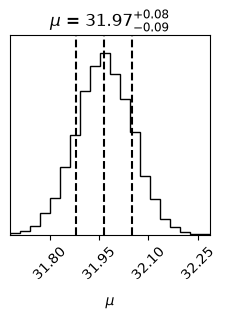

In [113]:
#Make corner plot
flat_samples = post_samples.numpy()

labels = [r"$\mu$"]
truths = [mu]

fig = cp.corner(flat_samples[:, :], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})



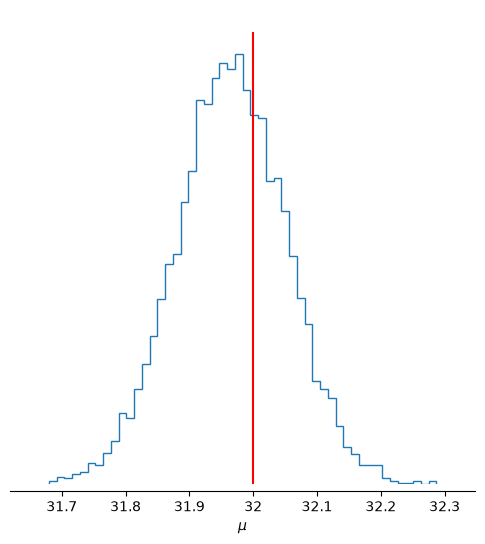

In [114]:
#plot the posterior from above
fig, axes = pairplot(
    post_samples,
    points=[32],        
    points_colors=["red"],
    labels=[r"$\mu$"],
    figsize=(6, 6),
)

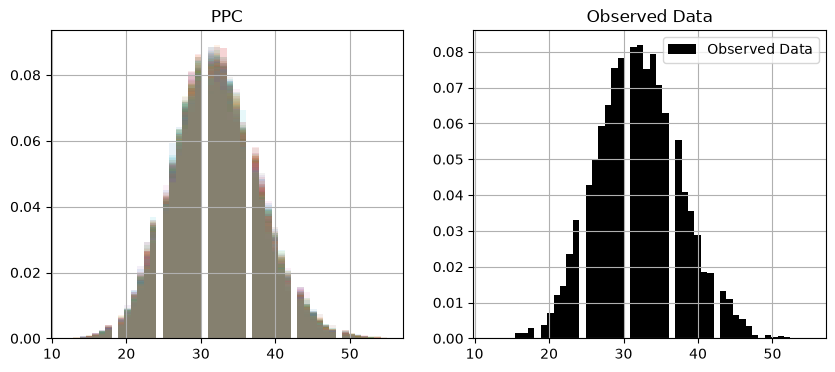

In [115]:
def replicate_posterior(theta_samp, n_obs, rng):
    theta_np = theta_samp.detach().cpu().numpy()
    mu = theta_np[:, 0][:, None]       
    return rng.poisson(lam=mu, size=(len(theta_np), n_obs))  

rng = np.random.default_rng(0)
y_rep = replicate_posterior(post_samples, n_obs=len(observed), rng=rng)

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10, 4))
bins = np.histogram_bin_edges(observed, bins=50)   

for i in range(100):
    ax1.hist(y_rep[i], bins=bins, density=True, alpha=0.1)

ax2.hist(observed, bins=bins, density=True,
        color='k', label='Observed Data')

ax1.set_title('PPC')
ax1.grid()
ax2.set_title('Observed Data')
ax2.grid()
ax2.legend()
plt.show()

Lognormal Distribution

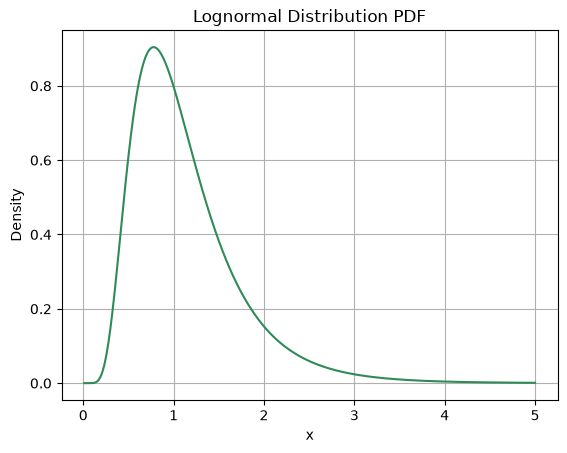

-0.125

In [169]:
#Lognormal distribution
sigma = 0.5
mu = -sigma**2 / 2
x = np.linspace(0.01, 5, 500)
lognormal_dist = lognorm.pdf(x, s=sigma, scale=1)

plt.plot(x, lognormal_dist,label=f'PDF (mu={mu}, sigma={sigma})', color='seagreen')
plt.title('Lognormal Distribution PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.grid(True)
plt.show()
mu


In [ ]:

n_cells = 100      
nbar = 30.0         
max_count = 150
bins = 50

prior = BoxUniform(low=torch.tensor([0.05]), high=torch.tensor([1.5]))

def simulator(theta):
    sigma = theta[0]
    g = torch.randn(n_cells) * sigma - sigma**2 / 2    
    rho = torch.exp(g)                                 
    counts = torch.poisson(nbar * rho)                 
    counts = counts.clamp(max=max_count)

    return torch.histc(counts, bins=bins, min=0, max=max_count) / n_cells

theta_train = prior.sample((5000,))
x_train = torch.stack([simulator(t) for t in theta_train])

inference = NPE(prior=prior)
inference.append_simulations(theta_train, x_train)
posterior = inference.build_posterior(inference.train())


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/neural_nets/net_builders/flow.py:165: UserWarning: In one-dimensional output space, this flow is limited to Gaussians
  x_numel = get_numel(


 Neural network successfully converged after 69 epochs.

  0%|          | 0/5000 [00:00<?, ?it/s]

tensor([0.3692]) tensor([0.0113])


In [180]:
x_o = simulator(torch.tensor([0.5]))
post_sampes = posterior.sample((5000,), x=x_o)
fig = cp.corner(post_samples[:, :], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

  0%|          | 0/5000 [00:00<?, ?it/s]

ImportError: Please install arviz or use a numpy array as input

Gamma Distribution

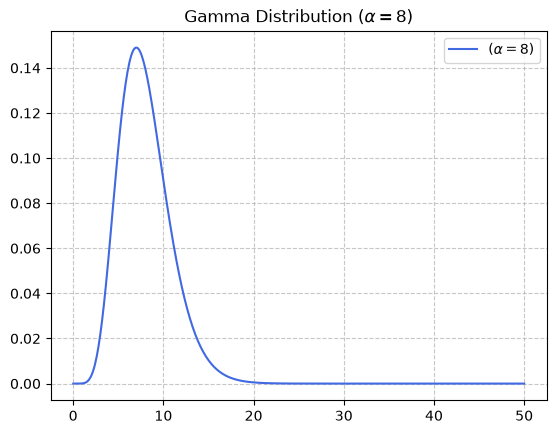

In [168]:
mu = 8 
x = np.linspace(0.01, 50, 500)

observed = gamma.pdf(x, a=mu)

plt.plot(x, observed, label=fr'($\alpha={mu}$)', color='royalblue')
plt.title(fr"Gamma Distribution ($\alpha={mu})$")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

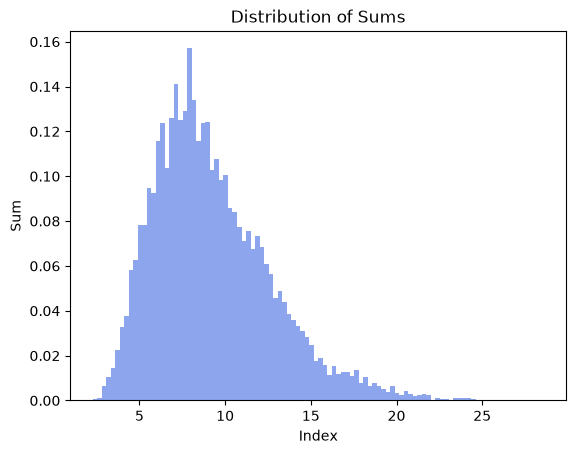

In [188]:
N=10000
sums = np.random.uniform(low=1, high=1.5, size=(N, 10)).prod(axis=1)
plt.hist(sums, bins =100, density=True, alpha=0.6, color='royalblue')
plt.xlabel('Index')
plt.ylabel('Sum')
plt.title('Distribution of Sums')
plt.show()
